# **From Curbside to Comfort: Connecting LA County’s Vehicle Residents with Parking Garage Vacancy**

**By Simon Han and Tomohiro Ujikawa, Prepared for UP213 Urban Data Science, SQ25**


## **Project Overview**

### Background
Vehicle residency is on the rise among working-class individuals and families as housing costs continue to outpace wages in Los Angeles and other big cities. On any given night in Los Angeles County, over 10,000 households sleep in cars, vans, or RVs, often within sight of nearly empty parking garages. We believe the county can close that gap by matching “hot-spot” streets where vehicle residents cluster with garages that already have access to basic utilities a Safe Parking program needs.

### Our Approach
- We started by collecting vehicle residency data and mapping spatial and temporal distributions
- Then, we explored socialeconomic and systemic factors that might have contributed to the spatial distribution patterns
- Finally, we analyzed discussions from an online forum to gather insight on amenities and services of interest to vehicle residents

### Key Questions
- How are vehicle residents clustered in Los Angeles?
- Which parts of Los Angeles have excess parking supply and high concentations of vehicle residents?

### Data Sources
- **TIGER/Line**: census tract boundaries
- **LAHSA Homeless Count**: unsheltered homeless and vehicle homeless count by tract
- **Census ACS**: poverty, rent burden, vehicle ownership, housing overcrowding, etc.
- **SCAG 2019 Regional Land Use Type**: "public parking facility", "residential", "industrial", "agricultural", etc.
- **LA GeoHub Public Amenities**: locations of essential services (hospitals, schools, transportation hubs, food pantries) for LA County
- **Reddit API**: 7000 posts and comments from r/urbancarliving

Data assumptions and Limitations: 
- "Public parking facility" parcels (land use code 1247 in the SCAG dataset) include stand-alone garages, park-and-ride lots, municipal and private lots that serve the general public. These parcels are selected because the land is already devoted to parking and would serve as low-conflict starting points for safe parking pilots. For this project, we assume all public parking facilities have access to amenities, such as lighting, weather protection, and safety features, typically found in parking garages.
- We used LAHSA vehicle homeless count data to understand vehicle residents' spatial patterns and identify suitable areas for vehicle residency. We acknowledge that vehicle residency, the act of living in a vehicle, includes a broad range of people, from those doing it by choice (e.g. vanlifers, digital nomads) to those doing it by necessity because they lack other stable housing options (i.e. vehicle homelessness). Despite these differences, we believe all who live in vehicles could benefit from access to legal and supportive parking options. While our map titles and labels use the term "vehicle homeless" to reflect the source of our data, our analysis and recommendations consider the broader spectrum of vehicle residency. 

### What We Did
1. Spatial Mapping
   
2. Machine Learning
   
3. Parking Supply Inventory
   
4. Natural Language Processing

### What We Learned
- Identified "hot-spot" tracts that overlap with a high concentration of parking facilities, suggesting potential pilot program locations.
- Industrial zones are key. Clusters are nearby warehouse and freight corridors where curb enforcement is loose, also where parking supply is plentiful.
- Housing cost is a trigger, but parking supply may be the lever. Neighborhoods where high rental prices exacerbate poverty rates should consider repurposing overnight parking supply as supplemental housing supply to better support residents.
- Resident priorities are pragmatic. The loudest sentiment signals are about safety, hygiene, and other small comforts, not luxury amenities, like education, healthcare, housing placement.

### What We Recommend
- Launch a garaged-based safe parking pilot in "hot-spot" census tracts identified through spatial analysis.
- Tie parking garage retrofits to comfort amenities identified through sentiment analysis.
  

---

## **1. Spatial Analysis**

### Load required libraries

In [1]:
import contextily as ctx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pickle
import os
import shapely
from shapely.ops import unary_union
from matplotlib.colors import ListedColormap
from matplotlib.path import Path
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing

### Land Use Analysis

Using pre-processed SCAG land use parcel data categorized by type (e.g. residential, commercial, industrial), we calculated the proportion of each land use type relative to the total tract area.

In [2]:
# Load pre-processed SCAG land use data from data prep notebook
luGdf = gpd.read_file("Data/landuse_processed.gpkg")
tracts19 = pd.read_pickle("data/tl_shp_library/tracts19.pkl")
tracts23 = pd.read_pickle("data/tl_shp_library/tracts23.pkl")

# Calculate residential land use proportion by tract
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]
luGdf_proj = luGdf.to_crs(epsg=3497)
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

# Group by tract and land use category
tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

# Pivot to wide format
tract_lu_wide = tract_lu.pivot(index='GEOID', columns='LU19_major_label', values='percent').reset_index()

# Clean column names
new_cols = ['GEOID']
for col in tract_lu_wide.columns[1:]:
    clean_col = f"pct_{col.lower().replace(' ', '_').replace(',', '').replace('&', 'and').replace('/', '_')}"
    new_cols.append(clean_col)

tract_lu_wide.columns = new_cols
landuse_cols = [col for col in tract_lu_wide.columns if col.startswith('pct_')]
tract_lu_wide[landuse_cols] = tract_lu_wide[landuse_cols].fillna(0)

# Merge with tracts23
tracts23 = tracts23.merge(tract_lu_wide, on='GEOID', how='left')
tracts23[landuse_cols] = tracts23[landuse_cols].fillna(0)

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Land use is categorized into 11 major types based on SCAG 2019 data</li>
<li>The proportion of each land use type is calculated for every census tract</li>
</ul>
</div>

### Amenities Analysis

Using pre-processed data on public facitily locations, we counted the number of each type of public facility and public parking facility within a 2km radius of each census tract.

In [3]:
# Load pre-processed public amenities data from data prep notebook
tracts23_buffer = pd.read_pickle("data/tl_shp_library/tracts23_buffer.pkl")
facilities = pd.read_pickle("data/public_facilities/facilities_dict.pkl") 
parking = pd.read_pickle("data/public_facilities/parking_centroids.pkl")

# Count facilities within tract buffers
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'
    tracts_gdf = tracts_gdf.join(counts)
    tracts_gdf[f'n_{buffer_gdf_name}'] = tracts_gdf[f'n_{buffer_gdf_name}'].fillna(0)
    return tracts_gdf

# Count all facility types
for facility_name, facility_gdf in facilities.items():
    tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, facility_gdf, facility_name)

# Count parking facilities
tracts23_buffer = tracts23_buffer.reset_index()
tmpgdf_ms = gpd.sjoin(tracts23_buffer, parking, predicate='intersects')
parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
parking_counts.name = 'n_Parking'
tracts23_buffer = tracts23_buffer.set_index('GEOID').join(parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

# Transfer amenity counts back to tracts23
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Created 2km buffers around census tracts for amenity analysis</li>
<li>Counted 9 types of facilities (parking, food pantries, hospitals, arts recreation, education, municipal services, physical features, public safety, transportation hubs)</li>
</ul>
</div>

### Homeless Count Data Processing

Using LAHSA homeless count data, we aggregated variables related to vehicle homelessness at the tract level.

In [4]:
# Process LAHSA homeless count data for years 2022-2024
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']
years = [22, 23, 24]

for year in years:
    hc = pd.read_csv(f"Data/LAHSA/streetcount{year}_original.csv")
    hc.columns = hc.columns.str.lower()
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')
    
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]
    
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()
    
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']
    hc_agg.to_csv(f"Data/LAHSA/streetcount{year}.csv", index=False)

# Process LAHSA data for 2020
hc20 = pd.read_csv('Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']
hc20 = hc20.set_index('GEOID')

for year in [22, 23, 24]:
    df = pd.read_csv(f"Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')
    globals()[f"hc{year}"] = df

# Create aggregated variables
hc22['totencamp'] = 0
for year in [20, 22, 23, 24]:
    df = globals()[f"hc{year}"]
    df.columns = df.columns.str.lower()
    df['total_vehicle'] = df[['totcars', 'totvans', 'totcampers']].fillna(0).sum(axis=1)
    df['total_unsheltered'] = df['total_vehicle'] + df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    df['non_vehicle_unsheltered'] = df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    globals()[f"hc{year}"] = df

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Loaded LAHSA annual homeless count data by census tract for 2020-2024</li>
<li>Created a total vehicle homeless count variable that added up car, van, and RV counts for each census tract</li>
</ul>
</div>

### American Community Survey Data

Using Census API, we pulled ACS variables related to socioeconomic status at the tract level.

In [5]:
# Load ACS data
base_path = "Data/ACS"
acs20 = pd.read_csv(os.path.join(base_path, "acs20.csv"), dtype={"GEOID": str})
acs22 = pd.read_csv(os.path.join(base_path, "acs22.csv"), dtype={"GEOID": str})
acs23 = pd.read_csv(os.path.join(base_path, "acs23.csv"), dtype={"GEOID": str})

# Calculate tract areas for density metrics
tracts23 = tracts23.to_crs(epsg=3497)
tracts23["area_km2"] = tracts23.geometry.area / 1e6
tracts23_geom = tracts23[["GEOID", "area_km2", "geometry"]].copy()

# Process ACS data to create analytical variables
def process_acs(df, tracts23_geom):
    # Rename key variables
    df = df.rename(columns={
        "B25077_001E": "median_home_value", 
        "B25064_001E": "median_gross_rent",
        "B25088_001E": "median_owner_costs_mortgage", 
        "B19083_001E": "gini",
        "B25001_001E": "n_total_units"
    })

    # Renter cost burden
    rent_burden_cols = ["B25070_004E", "B25070_005E", "B25070_006E", "B25070_007E"]
    rent_burden_names = ["pct_rent_30_34", "pct_rent_35_39", "pct_rent_40_49", "pct_rent_50plus"]
    for col, name in zip(rent_burden_cols, rent_burden_names):
        df[name] = np.where(df["B25070_001E"] > 0, df[col] / df["B25070_001E"] * 100, np.nan)

    # Owner cost burden
    owner_burden_cols = ["B25091_005E", "B25091_006E", "B25091_007E", "B25091_008E"]
    owner_burden_names = ["pct_owner_cost_30_34", "pct_owner_cost_35_39", "pct_owner_cost_40_49", "pct_owner_cost_50plus"]
    for col, name in zip(owner_burden_cols, owner_burden_names):
        df[name] = np.where(df["B25091_001E"] > 0, df[col] / df["B25091_001E"] * 100, np.nan)

    # Other percentages
    df["unemployment_rate"] = np.where(df["B23025_003E"] > 0, df["B23025_005E"] / df["B23025_003E"] * 100, np.nan)
    df["poverty_rate"] = np.where(df["B17001_001E"] > 0, df["B17001_002E"] / df["B17001_001E"] * 100, np.nan)
    df["public_assistance_rate"] = np.where(df["B19057_001E"] > 0, df["B19057_002E"] / df["B19057_001E"] * 100, np.nan)
    df["hud_rate"] = np.where(df["B25022_001E"] > 0, df["B25022_002E"] / df["B25022_001E"] * 100, np.nan)
    df["oldhouses_rate"] = np.where(df["B25034_001E"] > 0, df["B25034_002E"] / df["B25034_001E"] * 100, np.nan)
    df["hispanic_rate"] = np.where(df["B03003_001E"] > 0, df["B03003_003E"] / df["B03003_001E"] * 100, np.nan)
    df["imigration_rate"] = np.where(df["B07001_001E"] > 0, df["B07001_017E"] / df["B07001_001E"] * 100, np.nan)
    df["1phouseholds_rate"] = np.where(df["B11001_001E"] > 0, df["B11001_003E"] / df["B11001_001E"] * 100, np.nan)

    # Age groups
    age_65plus_cols = ["B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
                       "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E"]
    age_under18_cols = ["B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
                        "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E"]
    
    df["n_age_65plus"] = df[age_65plus_cols].astype(float).sum(axis=1)
    df["n_age_under18"] = df[age_under18_cols].astype(float).sum(axis=1)
    df["over65_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_65plus"] / df["B01001_001E"] * 100, np.nan)
    df["under18_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_under18"] / df["B01001_001E"] * 100, np.nan)

    # Overcrowding
    df["n_overcrowded_units"] = df[["B25014_003E", "B25014_004E"]].astype(float).sum(axis=1)
    df["overcrowded_rate"] = np.where(df["B25014_001E"] > 0, df["n_overcrowded_units"] / df["B25014_001E"] * 100, np.nan)

    # Merge with spatial data
    df = df.merge(tracts23, on="GEOID", how="left")
    df["housing_density"] = np.where(df["area_km2"] > 0, df["n_total_units"] / df["area_km2"], np.nan)

    return gpd.GeoDataFrame(df, geometry="geometry", crs=tracts23_geom.crs).to_crs(epsg=4326)

# Process all years
acs20 = process_acs(acs20, tracts23_geom)
acs22 = process_acs(acs22, tracts23_geom)
acs23 = process_acs(acs23, tracts23_geom)

# Clean negative values
for df in [acs20, acs22, acs23]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].map(lambda x: np.nan if x < 0 else x)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Processed 50+ ACS variables including housing costs, poverty, and demographics</li>
<li>Created derived metrics like overcrowding rate and housing density</li>
</ul>
</div>

### Data Integration

Join all processed data variables for further analysis.

In [6]:
# Check if processed data already exists, built if statement to save time processing a big data file each time
if os.path.exists("Data/joined_all.gpkg"):
    print("Loading existing processed data...")
    joined_all = gpd.read_file("Data/joined_all.gpkg", layer="joined_all")
    print(f"Loaded dataset shape: {joined_all.shape}")
else:
    print("Processing data from scratch...")

    # Join ACS and LAHSA data by year
    joined20 = acs20.join(hc20, on="GEOID", how="left", rsuffix="_hc")
    joined22 = acs22.join(hc22, on="GEOID", how="left", rsuffix="_hc")
    joined23 = acs23.join(hc23, on="GEOID", how="left", rsuffix="_hc")
    
    # Add year indicators
    joined20["year"] = 2020
    joined22["year"] = 2022
    joined23["year"] = 2023
    
    # Ensure GEOID columns are strings before concatenation
    for df in [joined20, joined22, joined23, tracts23]:
        df['GEOID'] = df['GEOID'].astype(str)
    
    # Combine all years
    joined_all = pd.concat([joined20, joined22, joined23], ignore_index=False)
    
    # Merge with land use data using the actual columns that exist
    merge_cols = ['GEOID'] + landuse_cols
    joined_all = joined_all.merge(tracts23[merge_cols].copy(), on="GEOID", how="left")
    joined_all[landuse_cols] = joined_all[landuse_cols].fillna(0.0)
    
    # Ensure it's a GeoDataFrame and set CRS
    joined_all = gpd.GeoDataFrame(joined_all, geometry="geometry", crs=tracts23.crs)
    joined_all = joined_all.to_crs(epsg=3497)
    
    # Print summary
    print(f"\nFinal dataset shape: {joined_all.shape}")
    print(f"Land use columns in final dataset: {len(landuse_cols)}")
    
    # Export
    joined_all.to_file("Data/joined_all.gpkg", layer="joined_all", driver="GPKG")
    joined_all.to_csv("Data/joined_all.csv", index=False)

Loading existing processed data...
Loaded dataset shape: (7494, 196)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Integrated LAHSA, ACS, and public amenities data for 2020, 2022, 2023</li>
<li>Created panel dataset with 2,700+ census tract observations</li>
</ul>
</div>

### Mapping Vehicle Homelessness Over Time

Initial study of the spatial distribution of vehicle residency.

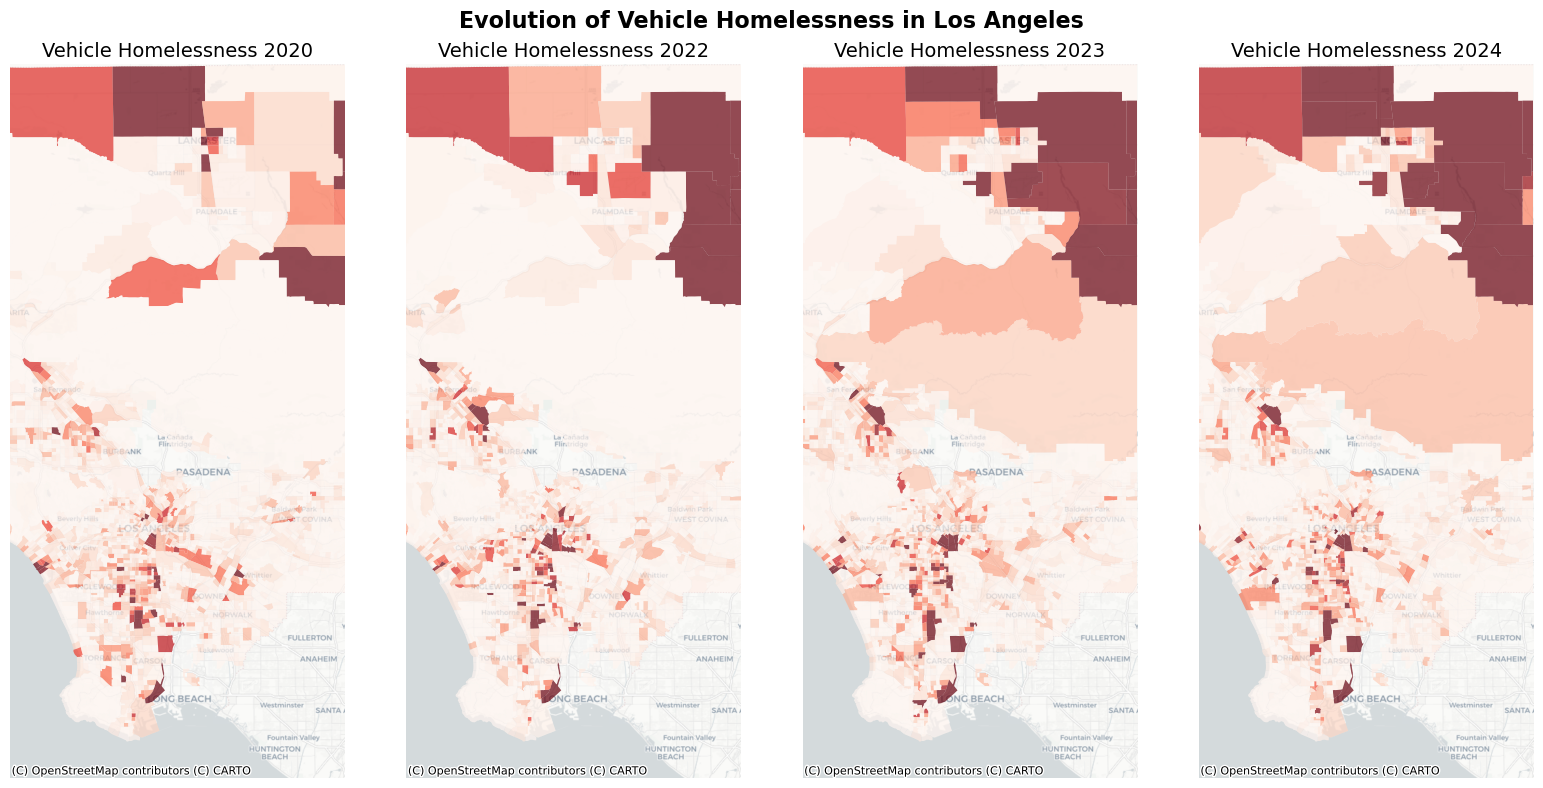

In [7]:
# Vehicle homelessness heat maps by year
years_data = [(hc20, tracts19, '2020'), (hc22, tracts19, '2022'), (hc23, tracts23, '2023'), (hc24, tracts23, '2024')]

# IMPORTANT: set resolution for plots (100 for screen, 300 for print)
dpi = 100

fig, axes = plt.subplots(1, 4, figsize=(16, 8), dpi=dpi)
for idx, (hc, tracts, year) in enumerate(years_data):
    # Merge and plot in one step
    gdf = gpd.GeoDataFrame(
        tracts.reset_index().merge(hc[['total_vehicle']].reset_index(), on='GEOID', how='left'),
        geometry='geometry', crs=tracts.crs
    ).to_crs(epsg=3857)
    
    gdf.plot(column='total_vehicle', cmap='Reds', ax=axes[idx], alpha=0.7, vmin=0, vmax=50, legend=False)
    ctx.add_basemap(axes[idx], source=ctx.providers.CartoDB.Positron, zoom=10)
    axes[idx].set_xlim(-13195000, -13120000)
    axes[idx].set_ylim(3980000, 4140000)
    axes[idx].set_title(f'Vehicle Homelessness {year}', fontsize=14)
    axes[idx].axis('off')

plt.suptitle('Evolution of Vehicle Homelessness in Los Angeles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## **2. Machine Learning Analysis**

### Random Forest Model
Build a Random Forest model to predict vehicle homelessness.

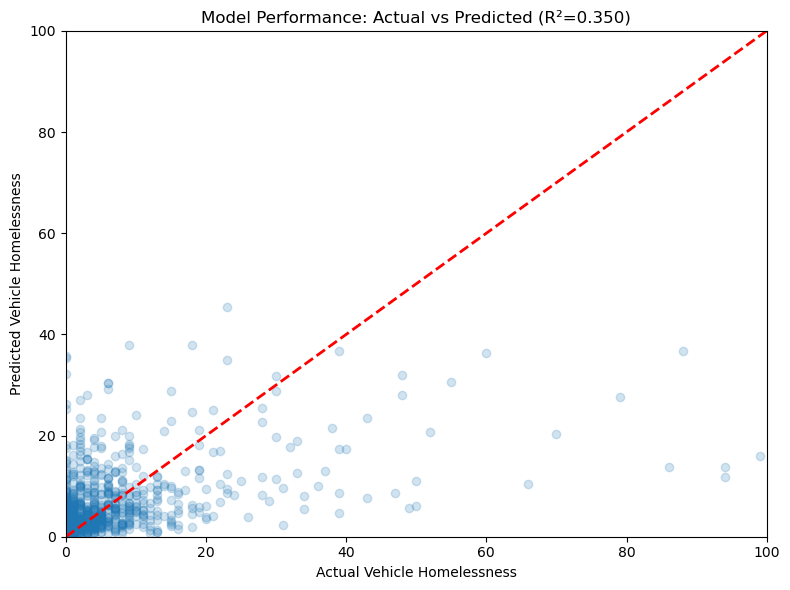

Samples: 5396, R²: 0.350, MAE: 6.4


In [8]:
# Model training and evaluation
features = [
    'year', 'non_vehicle_unsheltered', 'median_home_value', 'median_gross_rent', 'median_owner_costs_mortgage',
    'gini', 'unemployment_rate', 'poverty_rate', 'public_assistance_rate', 'hud_rate', 'oldhouses_rate',
    'hispanic_rate', 'imigration_rate', '1phouseholds_rate', 'over65_rate', 'under18_rate', 'overcrowded_rate',
    'housing_density', 'pct_rent_30_34', 'pct_rent_35_39', 'pct_rent_40_49', 'pct_rent_50plus',
    'pct_owner_cost_30_34', 'pct_owner_cost_35_39', 'pct_owner_cost_40_49', 'pct_owner_cost_50plus',
    'pct_residential', 'pct_commercial_and_services', 'pct_industrial', 'pct_transportation_communications_and_utilities',
    'pct_public_facilities', 'pct_open_space_and_recreation', 'pct_vacant', 'pct_water', 'pct_agriculture',
    'pct_undevelopable_or_protected_land', 'pct_landunknown', 'n_ArtsRecreation', 'n_Education', 'n_Hospitals',
    'n_MunicipalServices', 'n_PhysicalFeatures', 'n_PublicSafety', 'n_Transportation', 'n_Pantry', 'n_Parking'
]

# Train model in one step
df_clean = joined_all[features + ['total_vehicle']].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    df_clean[features], df_clean['total_vehicle'], test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=50, random_state=42).fit(X_train, y_train)
y_pred = rf.predict(X_test)
r2 = metrics.r2_score(y_test, y_pred)

# Plot results
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.2)
ax.plot([0, 100], [0, 100], 'r--', lw=2)
ax.set(xlabel='Actual Vehicle Homelessness', ylabel='Predicted Vehicle Homelessness',
       title=f'Model Performance: Actual vs Predicted (R²={r2:.3f})', xlim=(0, 100), ylim=(0, 100))
plt.tight_layout()
plt.show()

print(f"Samples: {len(df_clean)}, R²: {r2:.3f}, MAE: {metrics.mean_absolute_error(y_test, y_pred):.1f}")

<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li>Random-Forest model built on 30+ socioeconomic and amenity variables.</li>
    <li>Performs well for tracts with ≤ 20 vehicle residents.</li>
    <li>Because most data points cluster in the 0–20 range, the model often defaults to “near-zero” predictions.</li>
    <li>High-count hotspots (> 40 residents) are rare, so the model lacks training examples in that range and systematically under-predicts them.</li>
  </ul>
</div>

### Feature Importance

Identify key predictors of vehicle homelessness.

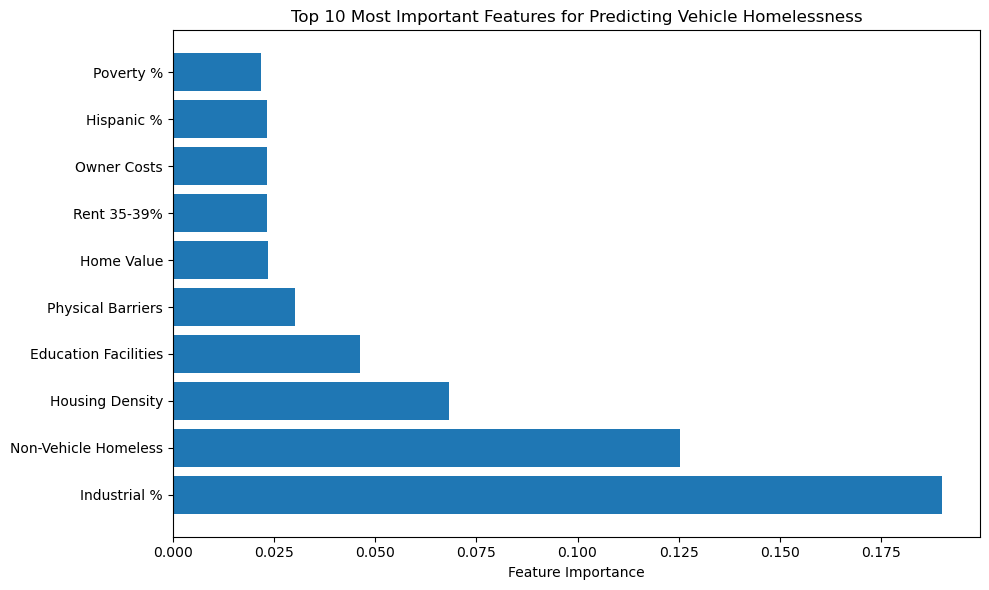

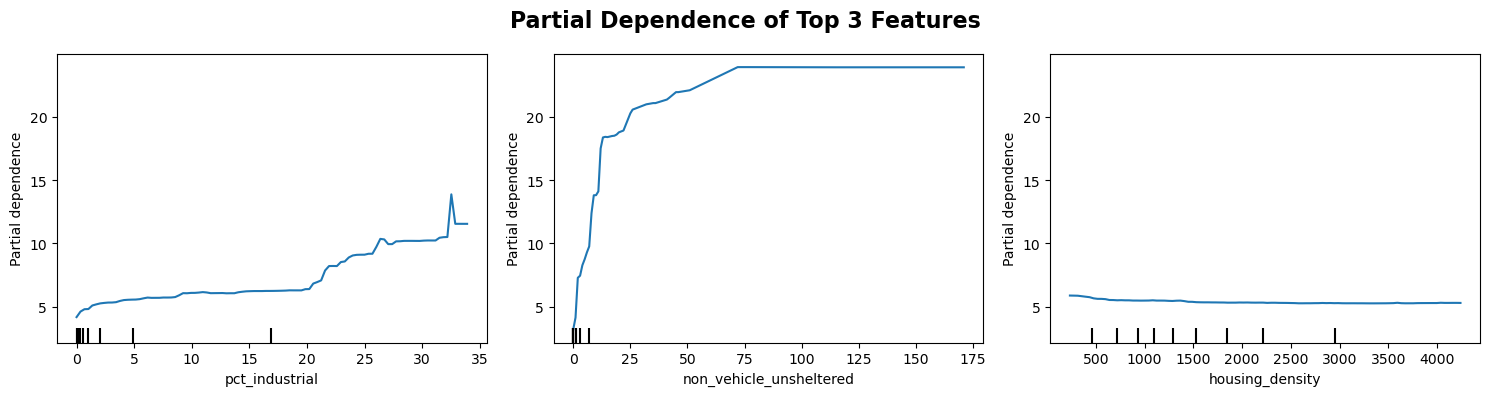

In [9]:
# Extract and visualize feature importances

# Feature name mapping
name_map = {
    'non_vehicle_unsheltered': 'Non-Vehicle Homeless', 'pct_industrial': 'Industrial %', 
    'housing_density': 'Housing Density', 'n_Education': 'Education Facilities',
    'n_PhysicalFeatures': 'Physical Barriers', 'n_Pantry': 'Food Pantries',
    'median_home_value': 'Home Value', 'median_gross_rent': 'Gross Rent',
    'median_owner_costs_mortgage': 'Owner Costs', 'pct_rent_35_39': 'Rent 35-39%',
    'pct_owner_cost_35_39': 'Owner Cost 35-39%', 'hispanic_rate': 'Hispanic %',
    'unemployment_rate': 'Unemployment %', 'poverty_rate': 'Poverty %',
    'public_assistance_rate': 'Public Assistance %', 'oldhouses_rate': 'Old Houses %',
    'imigration_rate': 'Foreign-Born %', '1phouseholds_rate': 'Single Households %',
    'overcrowded_rate': 'Overcrowded %', 'gini': 'Income Inequality',
    'pct_residential': 'Residential %', 'pct_commercial_and_services': 'Commercial %',
    'pct_vacant': 'Vacant Land %', 'n_Parking': 'Parking Lots', 'year': 'Year'
}

# Get top features
feature_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_df['readable'] = feature_df['feature'].map(name_map).fillna(feature_df['feature'])

# Plot importance
fig, ax = plt.subplots(figsize=(10, 6), dpi=dpi)
top10 = feature_df.head(10)
ax.barh(top10['readable'], top10['importance'])
ax.set(xlabel='Feature Importance', 
       title='Top 10 Most Important Features for Predicting Vehicle Homelessness')
plt.tight_layout()
plt.show()

# Partial dependence plots
top3_features = feature_df.head(3)['feature'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=dpi)
PartialDependenceDisplay.from_estimator(rf, X_test, top3_features, ax=axes)
plt.suptitle('Partial Dependence of Top 3 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li>“Hot-spot” tracts align with high industrial zoning and low residential zoning.</li>
    <li>Counts of tents and makeshift shelters are a useful proxy for vehicle residents.</li>
    <li>Place-based factors such as zoning and density have a bigger influence on where people park than how pricy housing is. Vehicle residents likely won't get hassled in industrial areas likely This suggests that the existing built environment. where This likely suggests that vehicle residents who recently moved out of housing would move away from there local neighborhoods in favor of parts of the city where they can park without being bothered</li>
    <li>Tracts that are dense (populated, well-lit, curb-constrained) attract fewer vehicle residents, which means that safe parking pilots could be more attractive if they targeted under-used garages in lower-density zones, such as industrial zones.</li>
  </ul>
</div>


### Cluster Analysis

Identify vehicle homelessness cluster typologies at the tract level.

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


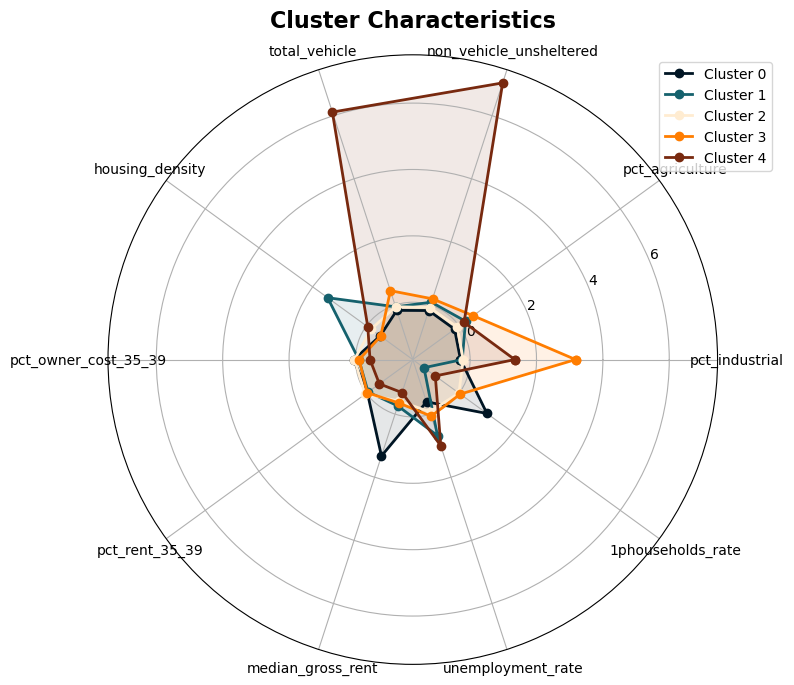

In [10]:
# Clustering and radar plot
features = ['pct_industrial', 'pct_agriculture', 'non_vehicle_unsheltered', 'total_vehicle', 
           'housing_density', 'pct_owner_cost_35_39', 'pct_rent_35_39', 'median_gross_rent', 
           'unemployment_rate', '1phouseholds_rate']

# Cluster in one step
cluster_data = joined_all[features].fillna(joined_all[features].mean())
scaler = preprocessing.StandardScaler()
cluster_scaled = pd.DataFrame(scaler.fit_transform(cluster_data), columns=features, index=cluster_data.index)
kmeans = KMeans(n_clusters=5, random_state=1).fit(cluster_scaled)
joined_all['cluster'] = kmeans.labels_

# Radar plot
def radar_plot(kmeans, features):
    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist() + [0]
    colors = ["#001524", "#15616D", "#FFECD1", "#FF7D00", "#78290F"]
    
    fig, ax = plt.subplots(figsize=(8, 8), dpi=dpi, subplot_kw=dict(projection='polar'))
    for i, center in enumerate(kmeans.cluster_centers_):
        values = center.tolist() + [center[0]]
        ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {i}', color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)
    ax.legend(bbox_to_anchor=(1.1, 1.0))
    plt.title('Cluster Characteristics', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

radar_plot(kmeans, features)

<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li><strong>Cluster 1 – Crowded & Shared</strong>: People who are single likely pay similar rent prices and tend to live in denser areas of the neighborhood.</li>
    <li><strong>Cluster 4 – Sparse & Solitary</strong>: People who live in vehicles often live near tents and makeshift shelters, which tend to be in areas with low residential density, high unemployment rate, and industrial zoning</li>
  </ul>
</div>


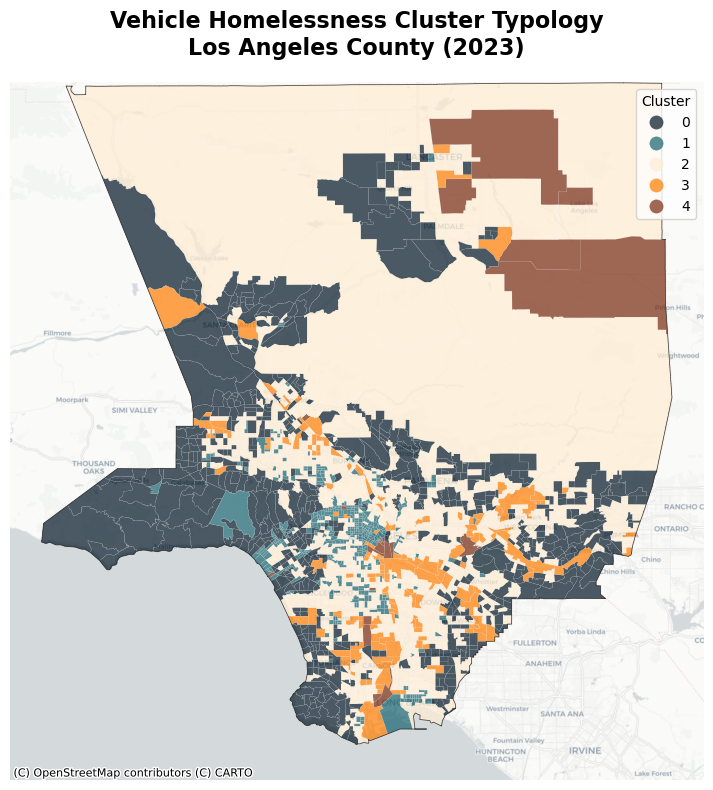

In [11]:
# Cluster map for 2023
colors = ["#001524", "#15616D", "#FFECD1", "#FF7D00", "#78290F"]
df = joined_all[joined_all['year'] == 2023].to_crs(epsg=3857)
df['cluster_label'] = df['cluster'].fillna(-1).astype(int)

fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)
tracts19.dissolve().to_crs(epsg=3857).boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.8)
df.plot(column='cluster_label', cmap=ListedColormap(colors), categorical=True, legend=True, 
        ax=ax, alpha=0.7, edgecolor='white', linewidth=0.1,
        legend_kwds={'title': 'Cluster', 'bbox_to_anchor': (1, 1)})

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
ax.set(ylim=(3980000, 4140000))
ax.set_title('Vehicle Homelessness Cluster Typology\nLos Angeles County (2023)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li><strong>Cluster 0 (dark navy) – Core Hot-Spots</strong><br>
        Vehicle dwellers pack into South LA, the Harbor–Gardena corridor, and parts of the Valley because these industrial streets offer plenty of overnight curb space and few complaints.</li>
    <li><strong>Cluster 1 (teal) – Service-Rich but Congested</strong><br>
        Downtown, Koreatown, Mid-City, and Hollywood stay busy: dense housing and pay-to-park streets deter long stays, yet nearby outreach services keep numbers from falling to zero.</li>
    <li><strong>Cluster 2 (cream) – Low-Count Suburbs</strong><br>
        The San Gabriel Valley, Westside hills, and planned suburbs show almost no vehicle homelessness—strict parking rules and ample private driveways leave little room to park overnight.</li>
    <li><strong>Cluster 3 (orange) – Spillover Zones</strong><br>
        Wilmington, El Monte, and several Gateway Cities sit between strict and loose enforcement. Counts swing after parking sweeps, so flexible night-permit programs could help here.</li>
    <li><strong>Cluster 4 (brown) – High-Desert Cold Zones</strong><br>
        Lancaster, Palmdale, and surrounding tracts see fewer cars but more stationary RVs. Large lots and scarce shelter options make designated RV zones the logical intervention.</li>
  </ul>
</div>


---

## **3. Parking Supply Analysis**

Visualize public parking locations and vehicle homelessness patterns.



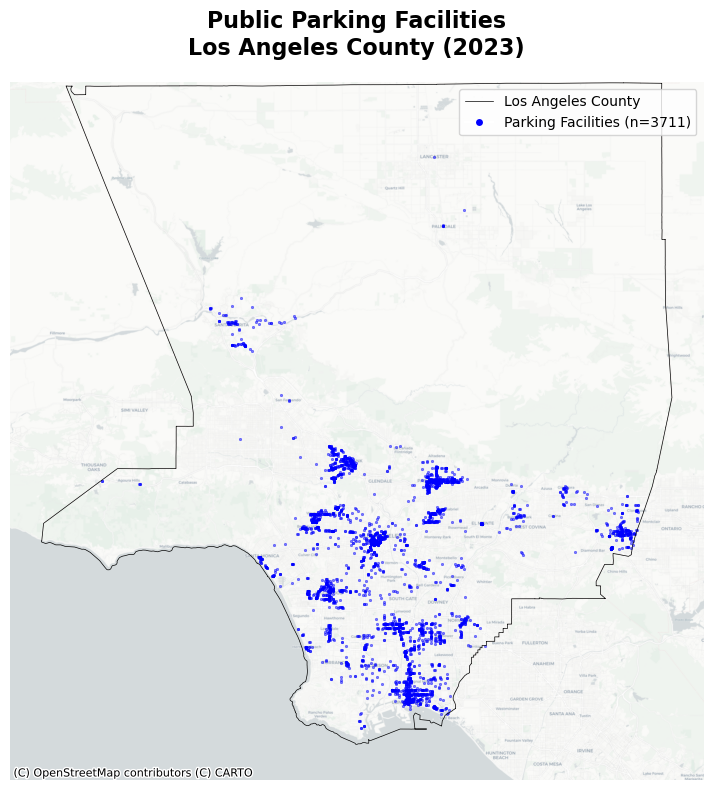

In [12]:
# Mapping of public parking parcel locations (from SCAG land use data) and Los Angeles County boundary
parking_web = parking.to_crs(epsg=3857)
parking_web = parking_web.drop_duplicates(subset='geometry')

la_county_boundary = tracts19.dissolve().to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)
la_county_boundary.boundary.plot(ax=ax, color='black', linewidth=0.5)
parking_web.plot(ax=ax, color='blue', markersize=3, alpha=0.5, linewidth=0.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

ax.set_ylim(3980000, 4140000)
handles = [
    Line2D([0], [0], color='black', linewidth=0.5, label='Los Angeles County'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, 
       label=f'Parking Facilities (n={len(parking_web)})')
]
ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=True)
ax.set_title('Public Parking Facilities\nLos Angeles County (2023)', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li>Parking in Santa Monica, Inglewood, Long Beach, Hollywood, Burbank, Downtown LA Core, Pasadena, Claremont is more abundant as compared to other areas in LA County.</li>
    <li>Areas with greater parking supply are less likely to reach full capacity than those with a limited parking supply.</li>
    <li>Cities like Glendale, Pasadena, and Long Beach already run premier, technology-integrated parking facilities, so carving out 30-50 stalls for a priced and managed program is mostly a policy decision, not an infrastructure one.</li>
    <li>Utilizing parking in surplus tracts avoids competing with neighborhoods that are already short on curb space (Hollywood, Westside beaches, San Fernando Valley, Antelope Valley).</li>
  </ul>
</div>


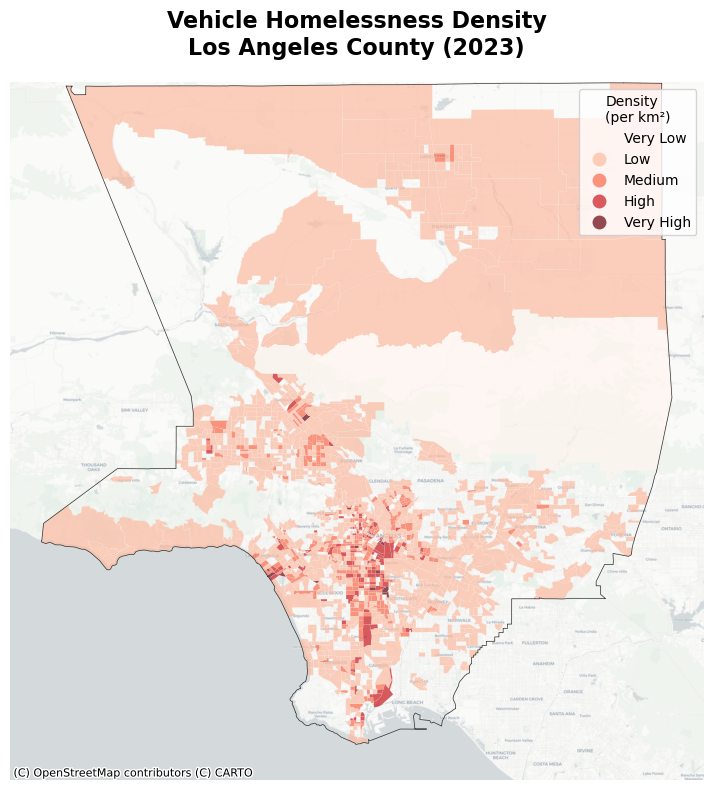

Vehicle homeless: 14,097.0
Tracts with vehicles: 1467

Top 5 Highest Density Areas:
            GEOID  total_vehicle  vehicle_density
6008  06037273502          163.0           207.21
6027  06037276101           50.0           153.22
5875  06037239802           91.0           149.31
5622  06037209105           12.0           144.19
6007  06037273404           28.0           129.01


In [13]:
# Import custom utility function
from jenks_utils import jenks_breaks

# Calculate vehicle density and classify
vehicle_2023 = joined_all[joined_all['year'] == 2023].copy()
vehicle_2023['vehicle_density'] = vehicle_2023['total_vehicle'] / vehicle_2023['area_km2'].fillna(0.01).replace(0, 0.01)
vehicle_data = vehicle_2023[vehicle_2023['vehicle_density'] > 0].to_crs(epsg=3857)

breaks = jenks_breaks(vehicle_data['vehicle_density'].values, 4)
vehicle_data['class'] = pd.cut(vehicle_data['vehicle_density'], 
                              bins=[-np.inf] + breaks + [np.inf],
                              labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)
tracts19.dissolve().to_crs(epsg=3857).boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.8)
vehicle_data.plot(column='class', cmap='Reds', categorical=True, alpha=0.7, edgecolor='white', 
                 linewidth=0.1, ax=ax, legend=True,
                 legend_kwds={'title': 'Density\n(per km²)', 'bbox_to_anchor': (1, 1)})
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_ylim(3980000, 4140000)
ax.set_title('Vehicle Homelessness Density\nLos Angeles County (2023)', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Summary stats
print(f"Vehicle homeless: {vehicle_2023['total_vehicle'].sum():,}")
print(f"Tracts with vehicles: {(vehicle_2023['total_vehicle'] > 0).sum()}")
print("\nTop 5 Highest Density Areas:")
print(vehicle_2023.nlargest(5, 'vehicle_density')[['GEOID', 'total_vehicle', 'vehicle_density']].round(2))

<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li><strong>Central LA Corridor</strong> – Westlake, Pico-Union, South-Central show the highest tract-level densities.</li>
    <li><strong>Harbor Waterfront</strong> – Wilmington, Harbor Gateway, and San Pedro industrial zones host a number of vehicle residents.</li>
    <li><strong>West Long Beach Freight Zone</strong> – Tracts west of I-710 near the rail yards and truck depots host a number of vehicle residents.</li>
    <li><strong>Venice Beach</strong> – Venice has wide commercial boulevards with ample curb space and light enforcement.</li>
  </ul>
</div>


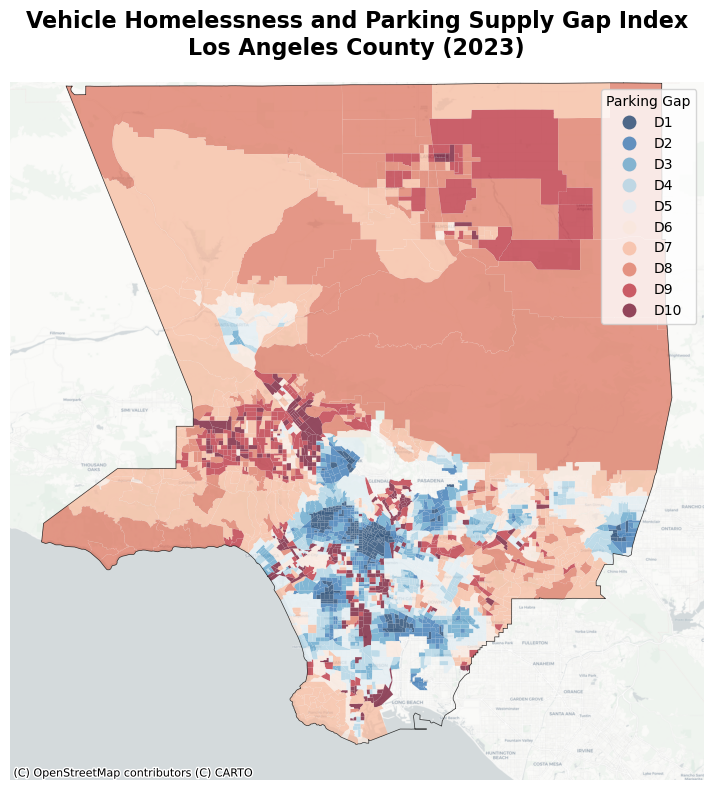

Top 5 Highest Gap Areas:
            GEOID  parking_gap_density  parking_gap_index
6008  06037273502               170.34               0.22
5875  06037239802               124.70               0.20
6740  06037535400               107.64               0.19
5031  06037104703               107.01               0.19
6739  06037535300                86.07               0.18

Top 5 Surplus Areas:
            GEOID  parking_gap_density  parking_gap_index
5595  06037207308            -44953.34             -24.43
5585  06037206302            -43815.46             -23.81
5594  06037207307            -42058.14             -22.85
5591  06037207304            -41079.34             -22.31
5621  06037209104            -28060.04             -15.20


In [14]:
# Parking gap analysis with color ramp in quantile

# Calculate densities and standardized gap index
area_clean = joined_all['area_km2'].fillna(0.01).replace(0, 0.01)
joined_all['vehicle_density_per_km2'] = joined_all['total_vehicle'] / area_clean
joined_all['parking_density_per_km2'] = joined_all['n_Parking'] / area_clean
joined_all['parking_gap_density'] = joined_all['vehicle_density_per_km2'] - joined_all['parking_density_per_km2']

gap_mean, gap_std = joined_all['parking_gap_density'].mean(), joined_all['parking_gap_density'].std()
joined_all['parking_gap_index'] = (joined_all['parking_gap_density'] - gap_mean) / gap_std

# Prepare 2023 data with decile classification
gdf_2023 = joined_all[joined_all['year'] == 2023].to_crs(epsg=3857)
decile_breaks = gdf_2023['parking_gap_index'].quantile(np.linspace(0.1, 0.9, 9)).values
gdf_2023['gap_class'] = pd.cut(gdf_2023['parking_gap_index'], 
                              bins=[-np.inf] + list(decile_breaks) + [np.inf],
                              labels=[f'D{i}' for i in range(1, 11)])

# Plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)
tracts19.dissolve().to_crs(epsg=3857).boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.8)
gdf_2023.plot(column='gap_class', cmap='RdBu_r', categorical=True, legend=True, alpha=0.7,
              edgecolor='white', linewidth=0.05, ax=ax,
              legend_kwds={'title': 'Parking Gap', 'bbox_to_anchor': (1, 1)})
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_ylim(3980000, 4140000)
ax.set_title('Vehicle Homelessness and Parking Supply Gap Index\nLos Angeles County (2023)', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Summary stats
print("Top 5 Highest Gap Areas:")
print(gdf_2023.nlargest(5, 'parking_gap_index')[['GEOID', 'parking_gap_density', 'parking_gap_index']].round(2))
print("\nTop 5 Surplus Areas:")
print(gdf_2023.nsmallest(5, 'parking_gap_index')[['GEOID', 'parking_gap_density', 'parking_gap_index']].round(2))

<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li><strong>Downtown LA Core</strong> – Public and office garages sit largely empty overnight, leaving surplus stalls despite only modest numbers of vehicle residents.</li>
    <li><strong>Glendale-Burbank</strong> – Shopping areas have far more night-time parking capacity than local vehicle residents can fill.</li>
    <li><strong>Pasadena</strong> – Historic-district traffic clears out after business hours, also leaving unused spaces for relatively few vehicle residents</li>
    <li><strong>South Bay Industrial Arc</strong> – Carson-Gardena lots stay underutilized at night, offering abundant parking well beyond nearby vehicle-homeless demand.</li>
  </ul>
</div>


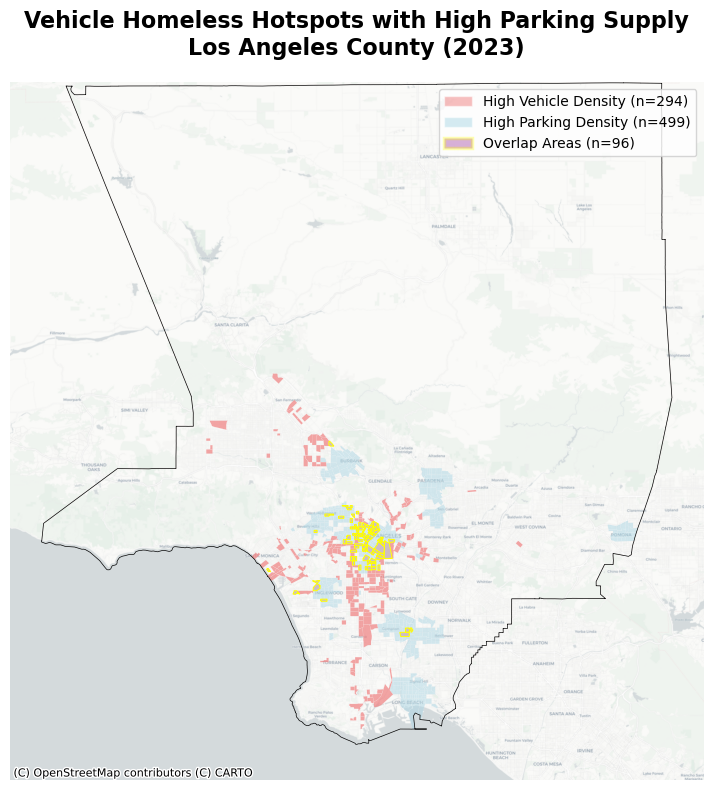

Tracts with high vehicle homeless density: 499
Tracts with high parking facilities density: 499
Overlap tracts (hot-spots with parking): 96


In [15]:
# Find vehicle homeless hot-spots with abundant parking
# Define thresholds for high vehicle density and high parking availability
vehicle_threshold = vehicle_data['vehicle_density'].quantile(0.8)  # Top 20% vehicle density
parking_threshold = gdf_2023['parking_density_per_km2'].quantile(0.8)  # Top 20% parking density

# Filter tracts meeting both criteria
hotspot_with_parking = gdf_2023[
    (gdf_2023['vehicle_density_per_km2'] >= vehicle_threshold) & 
    (gdf_2023['parking_density_per_km2'] >= parking_threshold)
].copy()

# Create visualization
fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)

# Base map
tracts19.dissolve().to_crs(epsg=3857).boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=1)

# Plot all high vehicle density areas in light red
high_vehicle = gdf_2023[gdf_2023['vehicle_density_per_km2'] >= vehicle_threshold]
high_vehicle.plot(ax=ax, color='lightcoral', alpha=0.7, edgecolor='white', linewidth=0.1)

# Plot all high parking areas in light blue
high_parking = gdf_2023[gdf_2023['parking_density_per_km2'] >= parking_threshold]
high_parking.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='white', linewidth=0.1)

# Highlight overlap areas in purple
hotspot_with_parking.plot(ax=ax, color='none', alpha=1, edgecolor='yellow', linewidth=0.7)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.set_ylim(3980000, 4140000)
handles = [
    mpatches.Patch(facecolor='lightcoral', edgecolor='white', alpha=0.5, 
                   label=f'High Vehicle Density (n={len(high_vehicle)})'),
    mpatches.Patch(facecolor='lightblue',  edgecolor='white', alpha=0.5, 
                   label=f'High Parking Density (n={len(high_parking)})'),
    mpatches.Patch(facecolor='purple',  edgecolor='yellow', alpha=0.3, linewidth=2.5,
                   label=f'Overlap Areas (n={len(hotspot_with_parking)})'),
]
ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=True)
ax.set_title('Vehicle Homeless Hotspots with High Parking Supply\nLos Angeles County (2023)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Tracts with high vehicle homeless density: {len(high_parking)}")
print(f"Tracts with high parking facilities density: {len(high_parking)}")
print(f"Overlap tracts (hot-spots with parking): {len(hotspot_with_parking)}")


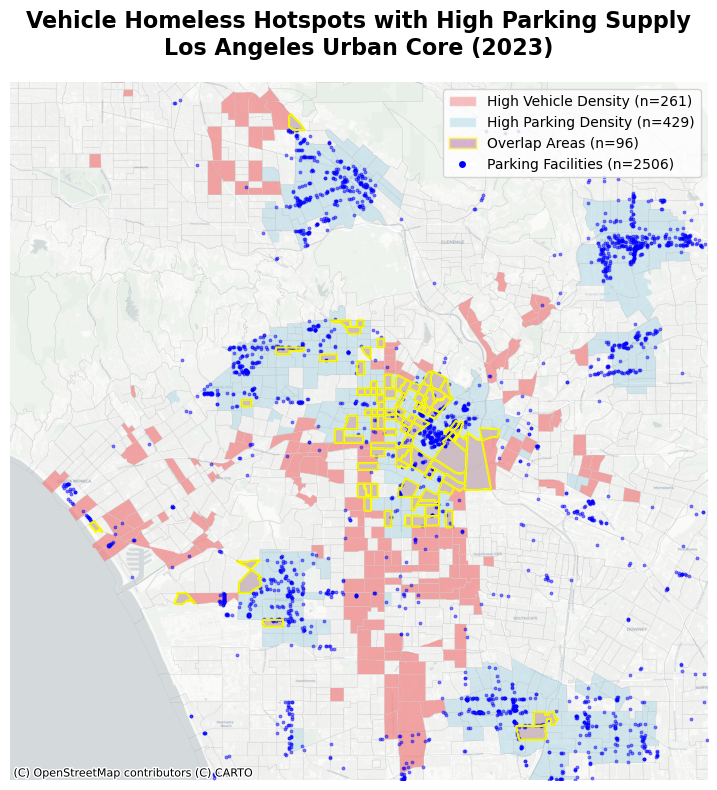

Tracts with high vehicle homeless density: 261
Tracts with high parking facilities density: 429
Overlap tracts (hot-spots with parking): 96


In [16]:
# Create zoomed-in map

minx, miny, maxx, maxy = -13195000, 4010000, -13145000, 4060000
fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)

# Plot base layers within extents
county_clip = tracts19.to_crs(epsg=3857).cx[minx:maxx, miny:maxy]
county_clip.boundary.plot(ax=ax, color='gray', linewidth=0.1, alpha=0.5)

# Plot high vehicle density areas
high_vehicle_clip = high_vehicle.cx[minx:maxx, miny:maxy]
high_vehicle_clip.plot(ax=ax, color='lightcoral', alpha=0.7, edgecolor='white', linewidth=0.2)

# Plot all high parking areas in light blue
high_parking = gdf_2023[gdf_2023['parking_density_per_km2'] >= parking_threshold]
high_parking_clip = high_parking.cx[minx:maxx, miny:maxy]
high_parking_clip.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='white', linewidth=0.1)

# Plot parking facilities in zoomed area
parking_clip = parking_web.cx[minx:maxx, miny:maxy]
parking_clip.plot(ax=ax, color='blue', markersize=5, alpha=0.5, linewidth=0.5)
    
# Highlight overlap areas
hotspot_with_parking.plot(ax=ax, color='none', edgecolor='yellow', linewidth=1.5)

# Add basemap and styling
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
handles = [
    mpatches.Patch(facecolor='lightcoral', edgecolor='white', alpha=0.5, 
                   label=f'High Vehicle Density (n={len(high_vehicle_clip)})'),
    mpatches.Patch(facecolor='lightblue',  edgecolor='white', alpha=0.5, 
                   label=f'High Parking Density (n={len(high_parking_clip)})'),
    mpatches.Patch(facecolor='purple',  edgecolor='yellow', alpha=0.3, linewidth=2.5,
                   label=f'Overlap Areas (n={len(hotspot_with_parking)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, 
       label=f'Parking Facilities (n={len(parking_clip)})')
]
ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=True)
ax.set_title('Vehicle Homeless Hotspots with High Parking Supply\nLos Angeles Urban Core (2023)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Tracts with high vehicle homeless density: {len(high_vehicle_clip)}")
print(f"Tracts with high parking facilities density: {len(high_parking_clip)}")
print(f"Overlap tracts (hot-spots with parking): {len(hotspot_with_parking)}")


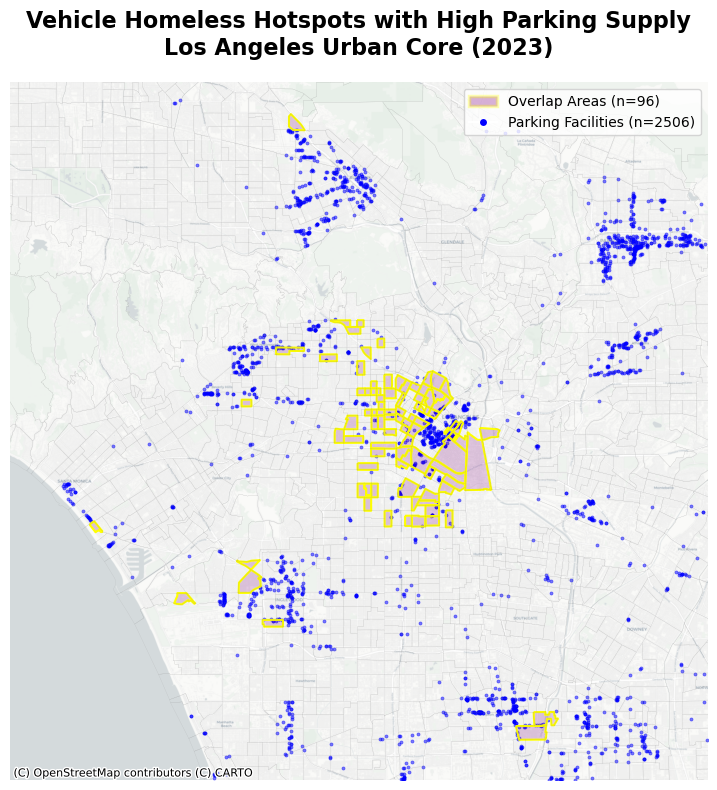

Out of 3711 parking facitlities in Los Angeles County, 2506 parking facilities are displayed in this map of the Los Angeles Urban Core.


In [17]:
# Create zoomed-in map

minx, miny, maxx, maxy = -13195000, 4010000, -13145000, 4060000

fig, ax = plt.subplots(figsize=(10, 8), dpi=dpi)

# Plot base layers within extents
county_clip = tracts19.to_crs(epsg=3857).cx[minx:maxx, miny:maxy]
county_clip.boundary.plot(ax=ax, color='gray', linewidth=0.1, alpha=0.5)

# Plot parking facilities in zoomed area
parking_clip = parking_web.cx[minx:maxx, miny:maxy]
parking_clip.plot(ax=ax, color='blue', markersize=5, alpha=0.5, linewidth=0.5)

# Overlap areas
hotspot_with_parking.plot(ax=ax, color='purple', alpha=0.2)
hotspot_with_parking.plot(ax=ax, color='none', edgecolor='yellow', linewidth=1.5)

# Add basemap and styling
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
handles = [
    mpatches.Patch(facecolor='purple',  edgecolor='yellow', alpha=0.3, linewidth=2.5,
                   label=f'Overlap Areas (n={len(hotspot_with_parking)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, 
       label=f'Parking Facilities (n={len(parking_clip)})')
]
ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=True)
ax.set_title('Vehicle Homeless Hotspots with High Parking Supply\nLos Angeles Urban Core (2023)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Out of {len(parking_web)} parking facitlities in Los Angeles County, {len(parking_clip)} parking facilities are displayed in this map of the Los Angeles Urban Core.") 


/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_40611/1836379905.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  parking_buffer_clip = parking_web[parking_web.intersects(hotspot_buffer.unary_union)]


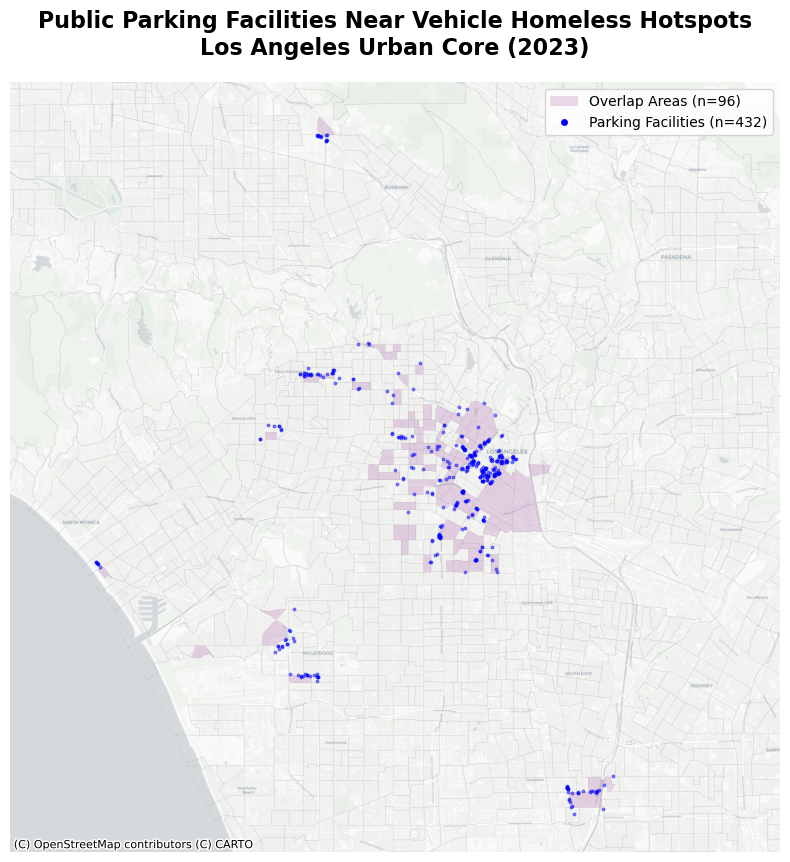

Out of 2506 parking facilities in the Los Angeles Urban Core, we found 432 parking facilities within 0.5km (~5-minute walk) of vehicle homeless hotspots.


In [18]:
# Create zoomed-in map with 2km buffer around hotspots

minx, miny, maxx, maxy = -13195000, 4010000, -13145000, 4060000

# Create .5km buffer around hotspot tracts and clip parking
hotspot_buffer = hotspot_with_parking.buffer(500)
parking_buffer_clip = parking_web[parking_web.intersects(hotspot_buffer.unary_union)]

fig, ax = plt.subplots(figsize=(8, 10), dpi=dpi)

# Plot base layers
county_clip = tracts19.to_crs(epsg=3857).cx[minx:maxx, miny:maxy]
county_clip.boundary.plot(ax=ax, color='gray', linewidth=0.1, alpha=0.5)

# Plot hotspot areas
hotspot_with_parking.plot(ax=ax, color='purple', alpha=0.15)

# Plot buffered parking facilities
parking_buffer_clip.plot(ax=ax, color='blue', markersize=5, alpha=0.5, linewidth=0.5)

# Styling
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
handles = [
    mpatches.Patch(facecolor='purple', alpha=0.15, 
                   label=f'Overlap Areas (n={len(hotspot_with_parking)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, 
       label=f'Parking Facilities (n={len(parking_buffer_clip)})')
]
ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=True)
ax.set_title('Public Parking Facilities Near Vehicle Homeless Hotspots\nLos Angeles Urban Core (2023)', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Out of {len(parking_clip)} parking facilities in the Los Angeles Urban Core, we found {len(parking_buffer_clip)} parking facilities within 0.5km (~5-minute walk) of vehicle homeless hotspots.")


<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
    <ul>
    <li><strong>Downtown–Central LA</strong> shows the densest overlap of red hot-spot tracts and blue parking facilities.</li>
    <li><strong>Around 1,500 parking facilities</strong> fall within vicinity to these hot-spot areas, showing ideal candidates for safe parking pilot.</li>
  </ul>
</div>

---

## **4. Natural Language Processing**

We pulled Reddit posts and comments data to understand what they enjoy about their way of life and the challenges they are facing. 

### Topic Modeling


In [19]:
from collections import Counter
import gensim
import pyLDAvis
import pyLDAvis.gensim_models

# Load 
wordlists = pd.read_pickle("data/reddit/wordlists-urbancarliving.pkl")
comments = pd.read_pickle("data/reddit/comments-urbancarliving.pkl")

# Analyze word frequencies
all_words = [word for wordlist in wordlists for word in wordlist]
word_freq = Counter(all_words)

print("Top 20 most common words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

Top 20 most common words:
car: 1976
good: 818
go: 779
work: 726
use: 714
make: 642
need: 618
keep: 594
living: 591
lot: 542
got: 527
want: 517
back: 513
life: 507
day: 506
sleep: 494
live: 477
going: 468
money: 462
parking: 456


In [20]:
# Run topic model
def run_topic_model(wordlists, num_topics=4, alpha=0.7, eta=0.5):
    dictionary = gensim.corpora.Dictionary(wordlists)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(wl) for wl in wordlists]
    
    model = gensim.models.LdaMulticore(
        corpus, 
        id2word=dictionary, 
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        random_state=1
    )
    
    return model, corpus, dictionary

# Run the model
model, corpus, dictionary = run_topic_model(wordlists, num_topics=4)

# Display topics
print("Topics found:")
print("=" * 50)

for idx, topic in model.show_topics(formatted=False, num_words=10):
    print(f"\nTopic {idx + 1}:")
    words = [word for word, prob in topic]
    print(f"{', '.join(words)}")

# Visualize topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
vis

Topics found:

Topic 1:
car, good, go, want, keep, work, need, living, make, money

Topic 2:
car, go, good, work, use, day, living, need, keep, got

Topic 3:
car, use, good, need, work, make, go, keep, back, living

Topic 4:
car, use, work, good, make, parking, go, lot, sleep, living


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.004441  0.000662       1        1  29.935478
0     -0.003683 -0.000226       2        1  27.115686
1      0.000185 -0.003709       3        1  21.918964
2     -0.000943  0.003272       4        1  21.029872, topic_info=         Term         Freq        Total Category  logprob  loglift
20        car  1781.000000  1781.000000  Default  30.0000  30.0000
221        go   700.000000   700.000000  Default  29.0000  29.0000
338   parking   420.000000   420.000000  Default  28.0000  28.0000
1116    looks   158.000000   158.000000  Default  27.0000  27.0000
9         use   644.000000   644.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
330      park    80.296098   400.316875   Topic4  -5.8735  -0.0473
42        lot    90.484869   495.118520   Topic4  -5.7541  -0.1404
434      life    81.060526   462.052175   Topic4  -5.8641  -0.1813
812       day    79.631191   457.845311   Topic4  -5.8818  -0.1899
77      sleep    75.204401   452.574164   Topic4  -5.9390  -0.2355

[356 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
3         1  0.346193  address
3         2  0.187521  address
3         3  0.317343  address
3         4  0.144247  address
5254      1  0.453138     adhd
...     ...       ...      ...
4321      4  0.141322       yr
6700      1  0.158425      yrs
6700      2  0.475274      yrs
6700      3  0.158425      yrs
6700      4  0.158425      yrs

[980 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 2, 3])

### Sentiment Analysis

In [21]:
from textblob import TextBlob

# Create dataframe with comments and polarity scores
sentiment_scores = [TextBlob(comment).sentiment.polarity for comment in comments]
df_sentiment = pd.DataFrame({
    'comment': comments,
    'polarity': sentiment_scores
})

# Display basic statistics
print(f"\nSentiment Statistics:")
print(f"Mean polarity: {df_sentiment['polarity'].mean():.3f}")
print(f"Median polarity: {df_sentiment['polarity'].median():.3f}")
print(f"Min polarity: {df_sentiment['polarity'].min():.3f}")
print(f"Max polarity: {df_sentiment['polarity'].max():.3f}")

# Categorize sentiments
df_sentiment['sentiment_category'] = df_sentiment['polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print(f"\nSentiment Distribution:")
print(df_sentiment['sentiment_category'].value_counts())

# Show examples
print(f"\nMost Positive Comments:")
print(df_sentiment.nlargest(10, 'polarity')[['comment', 'polarity']].to_string(max_colwidth=100))

print(f"\nMost Negative Comments:")
print(df_sentiment.nsmallest(10, 'polarity')[['comment', 'polarity']].to_string(max_colwidth=100))


Sentiment Statistics:
Mean polarity: 0.112
Median polarity: 0.059
Min polarity: -1.000
Max polarity: 1.000

Sentiment Distribution:
sentiment_category
Neutral     2980
Positive    2866
Negative     726
Name: count, dtype: int64

Most Positive Comments:
                                                                                                 comment  polarity
130                                                                                   Best power station       1.0
176                                                                 Ya Washington state is your best bet       1.0
196                                                                                      Looks delicious       1.0
218                                               Congrats and youre awesome for helping your sister out       1.0
224                                                                          Best brother ever Well done       1.0
416                                                     

parking: 337 comments found
inside: 133 comments found
outside: 141 comments found
apartment: 145 comments found
shower: 205 comments found
charge: 244 comments found
trash: 92 comments found
bathroom: 97 comments found
walmart: 133 comments found
street: 119 comments found
police: 91 comments found
guards: 20 comments found


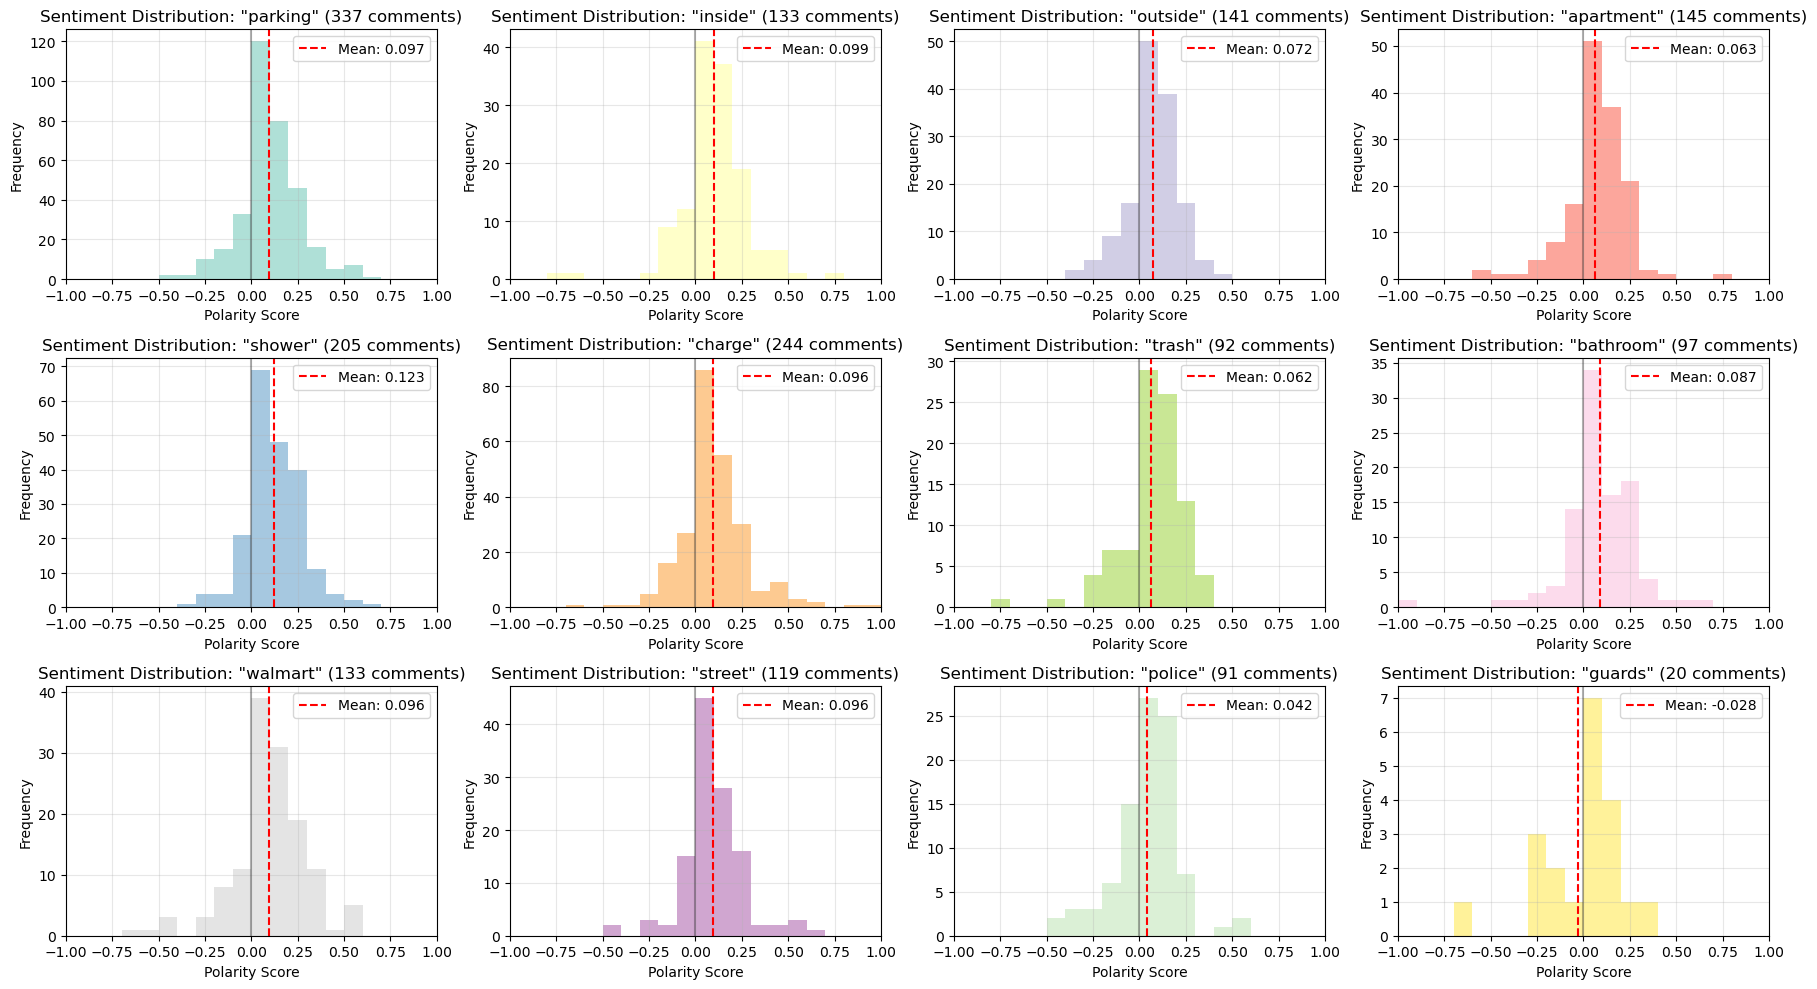

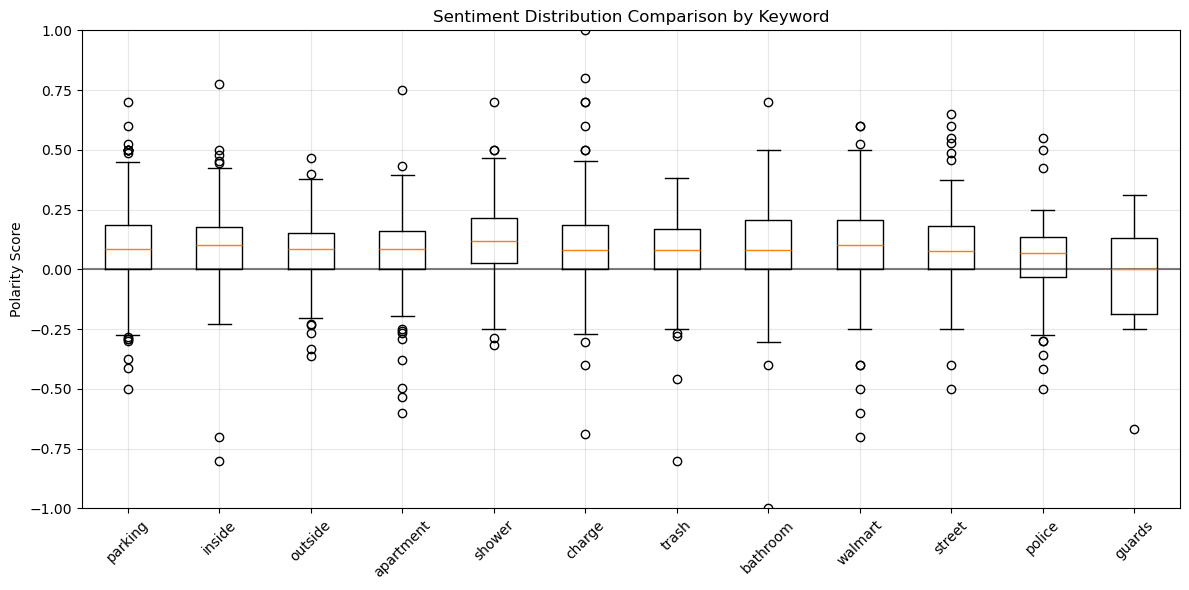

In [22]:
# Sentiment analysis 
keywords = ['parking', 'inside', 'outside', 'apartment', 'shower', 'charge', 'trash', 'bathroom', 'walmart', 'street', 'police', 'guards']

# Get sentiment data for all keywords
keyword_sentiments = {k: df_sentiment[df_sentiment['comment'].str.contains(k, case=False, na=False)]['polarity'] 
                     for k in keywords}

# Print counts
for k, v in keyword_sentiments.items():
    print(f"{k}: {len(v)} comments found")

# Create grid subplot
fig, axes = plt.subplots(3, 4, figsize=(18, 10), dpi=dpi)
axes = axes.flatten()
bins = np.linspace(-1, 1, 21)

for i, (k, v) in enumerate(keyword_sentiments.items()):
    axes[i].hist(v, bins=bins, alpha=0.7, color=plt.cm.Set3(i))
    axes[i].axvline(v.mean(), color='red', linestyle='--', label=f'Mean: {v.mean():.3f}')
    axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    axes[i].set_title(f'Sentiment Distribution: "{k}" ({len(v)} comments)')
    axes[i].set_xlabel('Polarity Score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(-1, 1)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plot - now synced with same keywords and data
valid_data = [(k, v) for k, v in keyword_sentiments.items() if len(v) > 0]

plt.figure(figsize=(12, 6))
plt.boxplot([v for k, v in valid_data], labels=[k for k, v in valid_data])
plt.title('Sentiment Distribution Comparison by Keyword')
plt.ylabel('Polarity Score')
plt.ylim(-1, 1)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
  <h3>Key Takeaways</h3>
  <ul>
    <li><strong>"parking"</strong> is more positive than <strong>"apartment"</strong>, <strong>"inside"</strong> is more positive than <strong>"outside"</strong>, but <strong>"outside"</strong> is still more positive than <strong>"apartment."</strong></li>
    <li><strong>"sleep"</strong> and <strong>"charge"</strong> are generally positive. <strong>"trash"</strong> and <strong>"bathroom"</strong> are less positive, suggesting that these could be welcomed amenity services if offered.</li>
    <li><strong>"walmart*"</strong> and <strong>"street"</strong> are generally positive. We think it demonstrates vehicle residents' optimism and resourcefulness in managing essential daily needs and necessities.</li>
    <li><strong>"police"</strong> and <strong>"guards"</strong> are significantly less positive than <strong>"walmart"</strong> and <strong>"street"</strong>. We think this suggests vehicle residents are less welcoming to guards.</li>
  </ul>
</div>


 *walmart is a popular destination for vehicle residents since most of its locations allow overnight parking in their big parking lots, no less free of charge

---

## **Conclusion**

For this project, we combined spatial analytics, machine-learning clustering, parking-inventory work, and natural-language processing to answer three practical questions.
#### Where is the need?
- Our spatial analysis identifies ~300 census tracts with high concentrations of vehicle homelessness, primarily in:
    - Downtown Los Angeles (DTLA)
    - Koreatown
    - South Central LA (including Vermont Square and Florence)
    - Westlake/MacArthur Park
    - Harbor Gateway and Wilmington
    - Van Nuys (San Fernando Valley)
    - Lancaster/Palmdale (far north)
    - South Bay cities (Carson, Torrance)
    - North Hollywood
#### Where is the slack?
- Out of the areas identified above, ~100 census tracts show both high concentrations of vehicle homelessness and proximity to high concentrations of public parking facilities. These areas, highlighted on the map, are prime candidates for garage-based safe parking interventions.

#### What do residents want?
- Our Reddit sentiment analysis of ~7000 comments in r/urbancarliving subreddit runs negatively around words like "outside", "trash", and "guards", which aligns with what parking garages could offer:
    - covered parking spaces sheltered from weather (as opposed to being outside exposed to the elements),
    - waste disposal/pickup service arrangements (as opposed to illegally dumping somewere),
    - technology-enhanced security monitoring systems and ample lighting solutions (as opposed to outsourcing private security guards)
#### What else?
- Routine tasks like showering and charging are presented positively in our sentiment analysis, suggesting residents’ ability to maintain a sense of normalcy despite not living in traditional housing. However, online sentiment shows that shared services that require collective management, such as safe parking, proper sanitation, and even social spaces, are received less positively. Providiing these services will likely have a wider impact on improving vehicle residents' well-being. Thankfully, garage-based safe parking can help bridge that gap as it's well-integrated with existing shared services.
#### **Our final takeaway is this:** 
Los Angeles already holds the vacant stalls, vehicle residents have spelled out their wishes, and our maps spotlight where the two converge. Shifting life from curbside survival to garage comfort is no longer a quest for insight, but a test of political will.